# Task 1: Dataset Exploration & Quality Audit

Two datasets, two modalities:

- **`lerobot/aloha_sim_insertion_human`** — simulated bimanual peg insertion. 50 episodes, 50 fps, 14 joints, one top camera. This is the teleop joint-state side.
- **`lerobot/svla_so100_pickplace`** — real SO100 arm doing pick-and-place. 50 episodes, 30 fps, 6 joints, **top + wrist cameras**. The wrist stream is our egocentric data (the prompt's named dataset has no wrist cam, so I picked one that does).

The audit logic lives in `src/audit.py` (joint states) and `src/video_quality.py` (video) as pure functions — this notebook calls them and looks at the results. Same functions get reused by the Task 3 curation pipeline, so what I explore here is literally what gets filtered there.

In [1]:
import sys, json
sys.path.insert(0, "..")   # so `src` imports from the repo root

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.load import LeRobotDataset
from src.audit import audit_episode, dataset_joint_ranges
from src.video_quality import episode_video_report, frame_metrics

aloha = LeRobotDataset("../data_raw/aloha_sim_insertion_human")
svla  = LeRobotDataset("../data_raw/svla_so100_pickplace")
print(aloha)
print(svla)
print("aloha joints:", aloha.joint_names)
print("svla joints: ", svla.joint_names)

ModuleNotFoundError: No module named 'cv2'

## 1. Episode profile — lengths and durations

First sanity question: what does a "normal" episode look like, and are there runts?

aloha_sim_insertion_human: frames min=500 median=500 max=500
svla_so100_pickplace: frames min=326 median=380 max=575


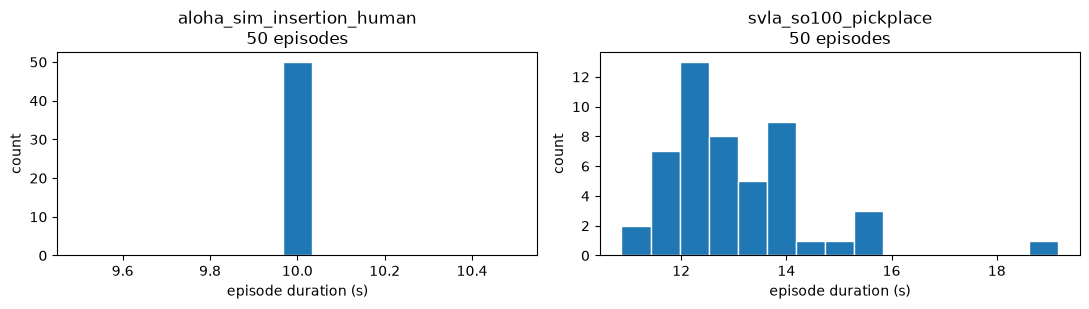

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.2))
for ax, ds in zip(axes, [aloha, svla]):
    secs = ds.episodes["length"] / ds.fps
    ax.hist(secs, bins=15, edgecolor="white")
    ax.set_title(f"{ds.name}\n{len(ds.episodes)} episodes")
    ax.set_xlabel("episode duration (s)"); ax.set_ylabel("count")
plt.tight_layout()

for ds in [aloha, svla]:
    L = ds.episodes["length"]
    print(f"{ds.name}: frames min={L.min()} median={int(L.median())} max={L.max()}")

**Finding:** aloha is exactly 500 frames (10.0 s) every single episode — it's a sim with a fixed recording window, so episode-length filtering is a no-op *here*. svla is real teleop: 326–575 frames (10.9–19.2 s), natural spread, no runts. On a real collection rig I'd still keep a minimum-length filter (aborted demos show up as 1–3 s stubs) — the check stays in the pipeline even though this particular data doesn't trigger it.

## 2. Joint-state audit — jumps, stalls, NaNs, timing

`src/audit.py` runs four checks per episode. Two design decisions worth calling out:

1. **Thresholds are robust + relative, not absolute.** aloha joints are radians (±1ish), svla is degrees (0–180). A jump is flagged against the episode's own delta distribution (median + MAD) **and** a physical floor: nothing sweeps its full joint range in under 0.25 s. My first version skipped the floor and flagged 500 "jumps" per episode — a joint that idles most of an episode has ~zero MAD, so every real motion looked like a teleport.
2. **The stall check auto-calibrates to the encoder.** The SO100's encoder is 12-bit quantized (min step 0.0879° = 360/4096; 43% of frames have zero delta on a joint) so bit-identical repeats are *normal* — only a full-state stall counts. The sim has float jitter at 1e-8, so per-joint exact repeats *would* be meaningful there.

In [ ]:
def run_audit(ds):
    ranges = dataset_joint_ranges(ds)
    rows = []
    for ep in ds.episodes["episode_index"]:
        f = ds.episode_frames(ep)
        r = audit_episode(ds.state_matrix(ep), f["timestamp"].to_numpy(), ds.fps, ranges)
        rows.append({"episode": int(ep), "n_jumps": r["jumps"]["n_jumps"],
                     "stall_frac": r["frozen"]["stall_fraction"],
                     "longest_stall_s": r["frozen"]["longest_stall_s"],
                     "n_nan": r["nans"]["n_nan"], "n_time_gaps": r["time"]["n_gaps"],
                     "_detail": r})
    return pd.DataFrame(rows)

audit_aloha = run_audit(aloha)
audit_svla  = run_audit(svla)

print("aloha: episodes with jump anomalies:", (audit_aloha.n_jumps > 0).sum(),
      "| NaNs:", audit_aloha.n_nan.sum(), "| timing gaps:", audit_aloha.n_time_gaps.sum())
print("svla : episodes with jump anomalies:", (audit_svla.n_jumps > 0).sum(),
      "| NaNs:", audit_svla.n_nan.sum(), "| timing gaps:", audit_svla.n_time_gaps.sum())
print("svla : episodes >30% fully stalled :", (audit_svla.stall_frac > 0.3).sum())
audit_aloha[audit_aloha.n_jumps > 0][["episode", "n_jumps"]]

aloha: episodes with jump anomalies: 8 | NaNs: 0 | timing gaps: 0
svla : episodes with jump anomalies: 0 | NaNs: 0 | timing gaps: 0
svla : episodes >30% fully stalled : 4


,episode,n_jumps
5,5,1
15,15,2
16,16,3
26,26,1
35,35,1
37,37,1
38,38,1
44,44,1


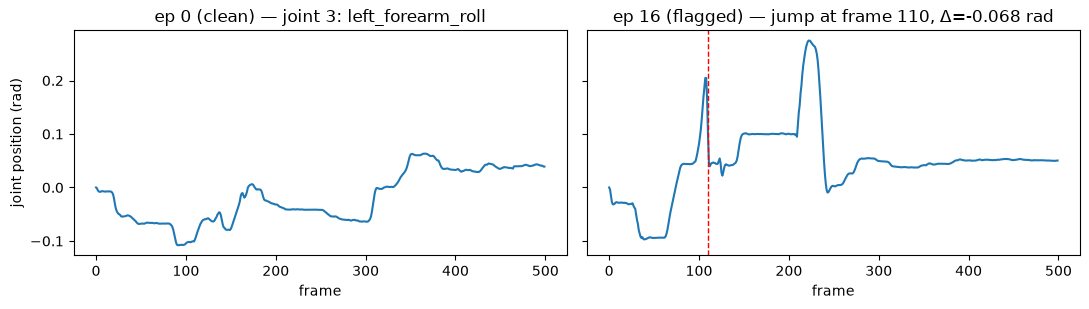

In [ ]:
# pick the flagged episode with the most jumps and show the offending joint trace
ep_bad = int(audit_aloha.loc[audit_aloha.n_jumps.idxmax(), "episode"])
detail = audit_aloha.loc[audit_aloha.episode == ep_bad, "_detail"].iloc[0]
jump = detail["jumps"]["jumps"][0]
j, f = jump["joint"], jump["frame"]

s_bad, s_ok = aloha.state_matrix(ep_bad), aloha.state_matrix(0)
fig, axes = plt.subplots(1, 2, figsize=(11, 3.2), sharey=True)
axes[0].plot(s_ok[:, j]); axes[0].set_title(f"ep 0 (clean) — joint {j}: {aloha.joint_names[j]}")
axes[1].plot(s_bad[:, j]); axes[1].axvline(f, color="red", ls="--", lw=1)
axes[1].set_title(f"ep {ep_bad} (flagged) — jump at frame {f}, Δ={jump['delta']:.3f} rad")
for ax in axes: ax.set_xlabel("frame")
axes[0].set_ylabel("joint position (rad)")
plt.tight_layout()

median stall fraction: 19.2% | longest single stall: 3.2s


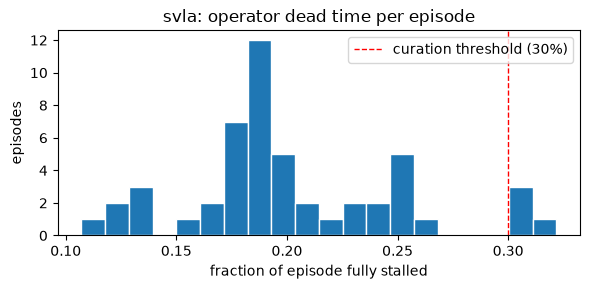

In [ ]:
# svla stalls: distribution of dead time across episodes
fig, ax = plt.subplots(figsize=(6, 3))
ax.hist(audit_svla.stall_frac, bins=20, edgecolor="white")
ax.axvline(0.3, color="red", ls="--", lw=1, label="curation threshold (30%)")
ax.set_xlabel("fraction of episode fully stalled"); ax.set_ylabel("episodes")
ax.set_title("svla: operator dead time per episode"); ax.legend()
plt.tight_layout()
print("median stall fraction:", f"{audit_svla.stall_frac.median():.1%}",
      "| longest single stall:", f"{audit_svla.longest_stall_s.max():.1f}s")

**Findings so far (teleop side):**

1. **8/50 aloha episodes contain single-frame teleports** — one joint moves an implausible amount in 20 ms. In sim these are likely controller/reset glitches; on a real robot this pattern means encoder misreads. Either way a policy shouldn't train on them.
2. **svla episodes are ~19% dead time at the median, 4 episodes above 30%** — full-state stalls where the operator paused. This isn't sensor dropout (you can't distinguish a pause from a bus stall using positions alone — you'd need comms-level logging on the rig), but dead time dilutes the training signal either way, so it's a curation criterion.
3. **Zero NaNs, zero timing gaps in both datasets** — expected for sim + a well-packaged HF release. The checks stay in: on a real collection rig, USB camera hiccups and serial-bus retries make timing gaps the *most* common defect.
4. **(structural) the SO100 encoder is quantized to 0.088°** — anything downstream that differentiates positions (velocity features, jerk metrics) must smooth first or it's differentiating a staircase.

## 3. Egocentric (wrist cam) quality 

Joint-state checks are *physical* (is this motion possible?). Video checks are *perceptual* (can a policy see anything in this frame?). `src/video_quality.py` computes per-frame blur (variance of Laplacian), exposure clipping, and frozen-frame detection.

The wrist cam needs different treatment than the top cam because it's bolted to the moving arm: motion blur tracks arm speed, the scene changes completely during an episode, and the gripper occludes the view at the most task-critical moments.

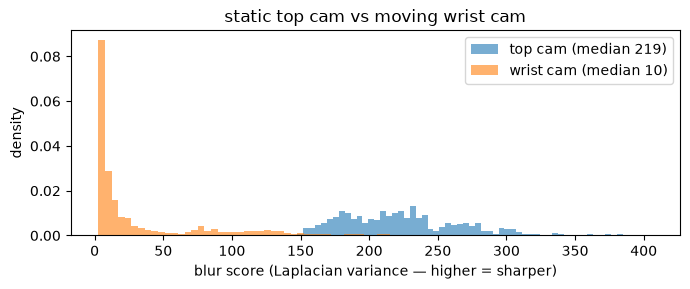

In [ ]:
# full wrist scan (all 50 eps), top-cam scan on a subset for comparison
wrist_reports = {int(ep): episode_video_report(svla, ep, "observation.images.wrist")
                 for ep in svla.episodes["episode_index"]}
top_reports = {int(ep): episode_video_report(svla, ep, "observation.images.top")
               for ep in list(svla.episodes["episode_index"])[:10]}

wrist_blurs = np.concatenate([[f["blur"] for f in r["frames"]] for r in wrist_reports.values()])
top_blurs   = np.concatenate([[f["blur"] for f in r["frames"]] for r in top_reports.values()])

fig, ax = plt.subplots(figsize=(7, 3))
ax.hist(top_blurs, bins=60, alpha=0.6, label=f"top cam (median {np.median(top_blurs):.0f})", density=True)
ax.hist(wrist_blurs, bins=60, alpha=0.6, label=f"wrist cam (median {np.median(wrist_blurs):.0f})", density=True)
ax.set_xlabel("blur score (Laplacian variance — higher = sharper)")
ax.set_ylabel("density"); ax.legend(); ax.set_title("static top cam vs moving wrist cam")
plt.tight_layout()

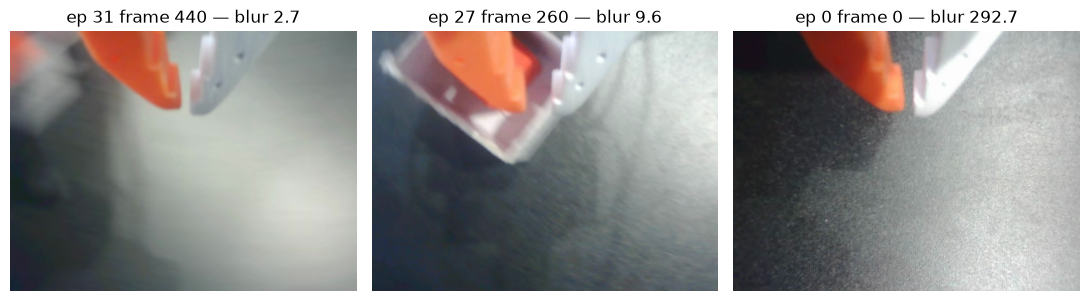

In [ ]:
# what do "sharp" and "blurry" actually look like on the wrist cam?
import cv2
flat = [(ep, f["frame"], f["blur"]) for ep, r in wrist_reports.items() for f in r["frames"]]
flat.sort(key=lambda x: x[2])
picks = [flat[0], flat[len(flat)//2], flat[-1]]   # worst, median, best

fig, axes = plt.subplots(1, 3, figsize=(11, 3))
for ax, (ep, fr, blur) in zip(axes, picks):
    for i, img in svla.video_frames(ep, "observation.images.wrist"):
        if i == fr:
            ax.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB)); break
    ax.set_title(f"ep {ep} frame {fr} — blur {blur:.1f}"); ax.axis("off")
plt.tight_layout()

worst episode: 29 at 9% | episodes over threshold: 0


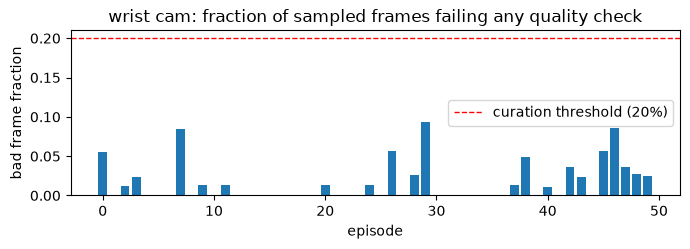

In [ ]:
# per-episode bad-frame fraction, wrist cam
bad = pd.Series({ep: r["bad_frame_fraction"] for ep, r in wrist_reports.items()})
fig, ax = plt.subplots(figsize=(7, 2.6))
ax.bar(bad.index, bad.values)
ax.axhline(0.20, color="red", ls="--", lw=1, label="curation threshold (20%)")
ax.set_xlabel("episode"); ax.set_ylabel("bad frame fraction"); ax.legend()
ax.set_title("wrist cam: fraction of sampled frames failing any quality check")
plt.tight_layout()
print(f"worst episode: {bad.idxmax()} at {bad.max():.0%} | episodes over threshold: {(bad > 0.2).sum()}")

**Findings (egocentric side):**

1. **The wrist cam is dramatically softer than the top cam.** It runs roughly an
   order of magnitude lower on Laplacian variance. That comes from the camera,
   the optics, and the motion rather than any defect. The consequence is that any
   absolute blur threshold tuned on the top cam would reject nearly every wrist
   frame, so all the video thresholds in this repo are set relative to each
   stream's own median.
2. **Blur comes in bursts rather than staying constant.** The bad frames cluster
   in fast reach and retract segments, sometimes up to around 9% of an episode.
   That is exactly why I filter conservatively, because a frame that is blurred
   because the arm is moving still carries real information about how the arm
   moves. Dropping those frames aggressively would select for slow demos and bias
   the learned policy toward moving slowly. This is the key place egocentric
   video parts ways with joint-state filtering, where a flagged frame is
   physically wrong and carries no usable signal at all.
3. **No frozen frames or exposure clipping showed up in this set,** but both
   checks stay armed anyway. USB wrist cams on real rigs drop to duplicated
   frames under bus contention all the time.

### How my filtering criteria differ between the two modalities

| | joint states | egocentric video |
|---|---|---|
| defect definition | physically impossible (teleports, NaN, stalls) | perceptually useless (blur, clipping, freezes) |
| threshold style | physical limits plus robust stats | percentiles relative to the stream |
| filter granularity | drop whole episodes | score frames, drop the episode only if more than 20% are bad |
| aggressiveness | strict, since a bad state is simply wrong | conservative, since a blurry frame is still informative |

The granularity row is the one that really matters for the pipeline. Deleting
individual video frames would break the 1:1 temporal alignment with the joint
stream, so frame-level defects get masks and only episode-level defects get
deletions. That rule is enforced in `src/curate.py` (Task 3).